# Part 2: Univariate analysis
- **Question:** What earns a 4.8+ on London Airbnb? Which listing and host features predict a top rating, so hosts know what to improve first.
- **Top rated** means an overall rating of 4.8 or higher (`top_rated` = 1).
- **How to read the figures:** each distribution is paired with a panel showing the share of rated listings in each group that are top rated, against the share for all rated listings (dashed red line). Each figure also says whether the variable is a **lever** (something a host can change) or **context** (fixed), and which bivariate figure (Part 3) tests it for significance.
- **Data:** `data/listings_clean.csv` from `01_cleaning.ipynb` (92,635 listings, 69 columns).
- **Goal:** describe each variable on its own (shape, center, spread, skew, outliers) and show how each is associated with a top rating, before the bivariate part tests the differences and the multivariate part models them together.
- **Samples:** general variables use all listings. Anything about the rating uses rated listings only (70,708).
- **Not used:** host response rate, acceptance rate and response time are empty in this snapshot. Review sub-scores and `host_is_superhost` are leakage for the model, so they are only described here, never used as features.

In [1]:
import json
from statistics import NormalDist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

BLUE, GREY, RED, INK = "#2471A3", "#95A5A6", "#C0392B", "#1C2833"

df = pd.read_csv("../data/listings_clean.csv", low_memory=False)
rated = df[df["top_rated"].notna()]
print(df.shape, "rated:", len(rated))


def clean_axes(ax):
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)


def cap_labels(s, cap, fmt="{:g}"):
    # Each value as a text label, with everything at or above `cap` grouped as "cap+"
    s = s.dropna()
    return s.where(s < cap, cap).map(lambda v: fmt.format(v) + ("+" if v >= cap else ""))


def bucket_counts(s, cap, fmt="{:g}"):
    # Share (%) of each value, with everything at or above `cap` grouped as "cap+"
    lab = cap_labels(s, cap, fmt)
    order = sorted(lab.unique(), key=lambda x: float(x.rstrip("+")))
    return (lab.value_counts(normalize=True) * 100).reindex(order)


def band_labels(s, bins, labels):
    return pd.cut(s, bins=bins, labels=labels, right=True)


def labelled_bins(s, bins, labels):
    return (band_labels(s, bins, labels).value_counts(normalize=True) * 100).reindex(labels)


def top_rate(d):
    # Share (%) of rated listings that are top rated: the dashed reference line on every rate panel
    return d["top_rated"].mean() * 100


def rate_by(labels, d, order, min_n=100):
    # Share (%) of rated listings in each group that are top rated; blank when a group has fewer than min_n rated listings
    y = d["top_rated"].dropna()
    g = y.groupby(labels.reindex(y.index), observed=True).agg(["mean", "size"])
    return (g["mean"] * 100).where(g["size"] >= min_n).reindex(order)


def bar_pct(ax, share, color=BLUE, horizontal=False):
    bars = (ax.barh if horizontal else ax.bar)(share.index.astype(str), share.values, color=color)
    ax.bar_label(bars, labels=[f"{v:.0f}%" if v >= 1 else "<1%" for v in share.values],
                 padding=2, fontsize=7)
    clean_axes(ax)
    return bars


def rate_dots(ax, rate, base, horizontal=False, na_text="too few"):
    # Top-rated share per group as dots, with the share for all rated listings as a dashed line
    pos = np.arange(len(rate))
    ok = rate.notna().values
    if horizontal:
        ax.scatter(rate[ok], pos[ok], s=36, color=INK, zorder=3)
        ax.axvline(base, color=RED, ls="--", lw=1)
        ax.set_yticks(pos, rate.index.astype(str))
        ax.set_xlabel("Top rated (% of rated listings)")
    else:
        ax.scatter(pos[ok], rate[ok], s=36, color=INK, zorder=3)
        ax.axhline(base, color=RED, ls="--", lw=1)
        ax.set_xticks(pos, rate.index.astype(str))
        ax.set_ylabel("Top rated (%)")
    for i, v in zip(pos, rate):
        txt, val = (f"{v:.0f}%", v) if pd.notna(v) else (na_text, base)
        ax.annotate(txt, (val, i) if horizontal else (i, val), xytext=(6, 0) if horizontal else (0, 7),
                    textcoords="offset points", ha="left" if horizontal else "center",
                    va="center" if horizontal else "bottom", fontsize=7, color=GREY if pd.isna(v) else INK)
    vals = np.append(rate.dropna().values, base)
    (ax.set_xlim if horizontal else ax.set_ylim)(max(0, vals.min() - 10), min(100, vals.max() + 12))
    clean_axes(ax)


def with_share(rate, share):
    # Relabel each group as "group (x%)" so a rate panel also shows how common the group is
    return rate.rename(lambda k: f"{k}\n({share[k]:.0f}%)")


def share_and_rate(ax_share, ax_rate, share, rate, base, color=BLUE, horizontal=False, na_text="too few"):
    # Share of listings per group (bars) and the top-rated share of the same groups (dots), lined up group by group
    bar_pct(ax_share, share, color=color, horizontal=horizontal)
    rate_dots(ax_rate, rate.reindex(share.index), base, horizontal=horizontal, na_text=na_text)
    if horizontal:
        ax_rate.set_ylim(ax_share.get_ylim())
        ax_rate.tick_params(labelleft=False)
    else:
        ax_rate.set_xlim(ax_share.get_xlim())
        ax_share.tick_params(labelbottom=False)


def iqr_fences(s):
    # Tukey fences: values outside Q1 - 1.5*IQR and Q3 + 1.5*IQR count as outliers
    q1, q3 = s.quantile([0.25, 0.75])
    return q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)


def n_outside(s):
    lo, hi = iqr_fences(s)
    return int(((s < lo) | (s > hi)).sum())


def box_h(ax, s, color=BLUE):
    # Horizontal box plot; points beyond the 1.5*IQR whiskers drawn small and faint
    ax.boxplot(s, orientation="horizontal", widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.35, edgecolor=color),
               medianprops=dict(color=RED), whiskerprops=dict(color=color), capprops=dict(color=color),
               flierprops=dict(marker=".", markersize=2, markerfacecolor=GREY, markeredgecolor="none", alpha=0.3))
    ax.set_yticks([])
    clean_axes(ax)


def qq_normal(ax, s, color=BLUE, n=400):
    # Standardised data quantiles against normal quantiles; points on the dashed line mean a normal shape
    probs = (np.arange(1, n + 1) - 0.5) / n
    theo = np.array([NormalDist().inv_cdf(q) for q in probs])
    z = (s - s.mean()) / s.std()
    ax.scatter(theo, np.quantile(z, probs), s=6, color=color)
    ax.plot([theo[0], theo[-1]], [theo[0], theo[-1]], color=RED, ls="--", lw=1)
    ax.set_xlabel("Normal quantiles")
    ax.set_ylabel("Data quantiles (z-score)")
    clean_axes(ax)

(92635, 69) rated: 70708


## Step 1: Summary statistics
Center, spread, skew and tails of the main numeric variables.
- **Skew** above 1 means a long right tail (below -1, a long left tail); these variables need log scales or grouping in charts.
- **Kurtosis** is excess kurtosis: 0 for a normal distribution, above 3 means heavy tails with many extreme values.
- **IQR fences** are Q1 - 1.5·IQR and Q3 + 1.5·IQR; `n_outliers` counts listings outside them. Step 2 judges whether the extremes are real.

In [2]:
num_cols = ["review_scores_rating", "price_capped", "accommodates", "bedrooms", "beds", "bathrooms",
            "minimum_nights", "availability_365", "number_of_reviews", "reviews_per_month",
            "estimated_occupancy_l365d", "calculated_host_listings_count", "hosts_time_as_host_years"]
summary = df[num_cols].describe().T
summary["missing_pct"] = (df[num_cols].isna().mean() * 100).round(1)
summary["skew"] = df[num_cols].skew()
summary["kurtosis"] = df[num_cols].kurt()
summary[["iqr_low", "iqr_high"]] = [iqr_fences(df[c].dropna()) for c in num_cols]
summary["n_outliers"] = [n_outside(df[c].dropna()) for c in num_cols]
summary["outlier_pct"] = summary["n_outliers"] / summary["count"] * 100
display(summary.round(2))

heavy = summary["kurtosis"].sort_values(ascending=False)
most_out = summary["outlier_pct"].sort_values(ascending=False)
display(Markdown(
    f"**Insight:** {(summary['kurtosis'] > 3).sum()} of {len(num_cols)} variables have excess kurtosis above 3 (heavy tails), "
    f"led by `{heavy.index[0]}` ({heavy.iloc[0]:,.0f}) and `{heavy.index[1]}` ({heavy.iloc[1]:,.0f}). "
    f"The IQR fences flag the largest share of listings in `{most_out.index[0]}` ({most_out.iloc[0]:.0f}%) and "
    f"`{most_out.index[1]}` ({most_out.iloc[1]:.0f}%). For skewed variables most of these points are the normal long tail, "
    f"not errors, so they are not removed on the fence rule alone. Only `availability_365` and `hosts_time_as_host_years` "
    f"have negative kurtosis (flat, no outliers)."))

,count,mean,std,min,25%,50%,75%,max,missing_pct,skew,kurtosis,iqr_low,iqr_high,n_outliers,outlier_pct
review_scores_rating,70708.0,4.69,0.48,1.00,4.60,4.83,5.00,5.00,23.7,-3.94,22.17,4.00,5.60,2840,4.02
price_capped,62238.0,244.37,225.07,2.23,100.00,180.00,300.10,1373.46,32.8,2.54,8.14,-200.15,600.24,3963,6.37
accommodates,92635.0,3.39,2.12,1.00,2.00,3.00,4.00,16.00,0.0,1.62,4.00,-1.00,7.00,4848,5.23
bedrooms,68653.0,1.77,1.04,0.00,1.00,1.00,2.00,30.00,25.9,2.92,32.76,-0.50,3.50,4523,6.59
beds,60161.0,2.02,1.45,1.00,1.00,2.00,3.00,50.00,35.1,3.38,38.40,-2.00,6.00,847,1.41
bathrooms,92509.0,1.33,0.69,0.00,1.00,1.00,1.50,30.00,0.1,4.79,87.21,0.25,2.25,7393,7.99
minimum_nights,92630.0,4.56,20.90,1.00,1.00,2.00,3.00,1125.00,0.0,26.13,1011.93,-2.00,6.00,9231,9.97
availability_365,92635.0,152.66,141.13,0.00,0.00,127.00,301.00,365.00,0.0,0.25,-1.58,-451.50,752.50,0,0.00
number_of_reviews,92635.0,24.15,55.08,0.00,1.00,5.00,23.00,1959.00,0.0,6.52,82.87,-32.00,56.00,10574,11.41
reviews_per_month,70711.0,0.99,1.32,0.01,0.14,0.49,1.28,32.17,23.7,3.13,22.05,-1.57,2.99,5683,8.04


**Insight:** 10 of 13 variables have excess kurtosis above 3 (heavy tails), led by `minimum_nights` (1,012) and `bathrooms` (87). The IQR fences flag the largest share of listings in `calculated_host_listings_count` (15%) and `estimated_occupancy_l365d` (12%). For skewed variables most of these points are the normal long tail, not errors, so they are not removed on the fence rule alone. Only `availability_365` and `hosts_time_as_host_years` have negative kurtosis (flat, no outliers).

## Figure 5: The target, overall rating
Left: how ratings are spread, with the 4.8 cut point. Right: how that cut splits rated listings into the two classes.

This is the outcome itself. Every later figure compares each group against the overall top-rated share shown here (the dashed red line).

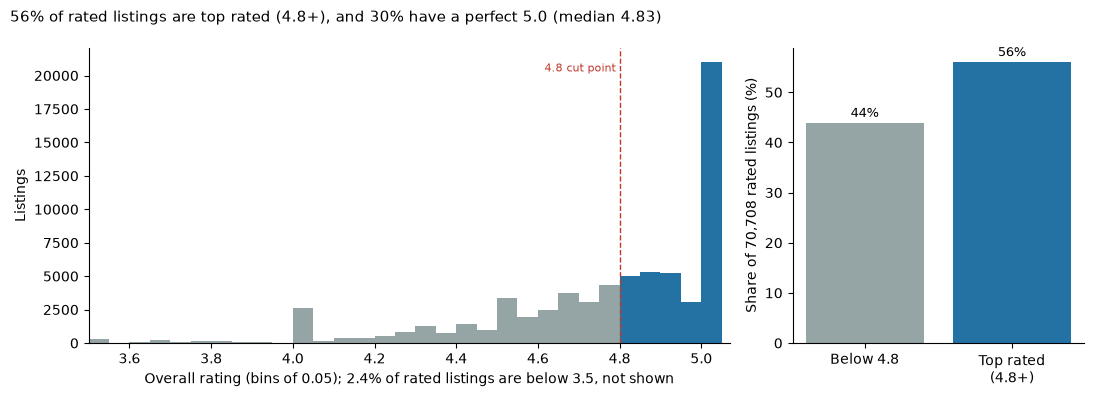

**Insight:** the rating is strongly left-skewed (skew -3.9); the middle half of rated listings lies between 4.60 and 5.00, and only 4% score below 4.0. The 4.8 cut point gives fairly balanced classes (56% vs 44%), so the model does not need resampling, but the classes are separated by small rating differences. Kurtosis is 22: 2,840 listings (4%) sit below the lower IQR fence of 4.00. These are real guest scores, so they are kept. The shape has a long lower tail and a flat top where scores hit the 5.0 ceiling. No transform removes a ceiling, which is why the rating is used as a binary target (`top_rated`) rather than a number.

In [3]:
def prep_fig5(d):
    r = d[d["top_rated"].notna()]
    rt = r["review_scores_rating"]
    share = r["top_rated"].map({1: "Top rated\n(4.8+)", 0: "Below 4.8"}).value_counts(normalize=True) * 100
    return dict(rt=rt, n_rated=len(r), target_share=share.reindex(["Below 4.8", "Top rated\n(4.8+)"]),
                lo_r=iqr_fences(rt)[0])


def draw_fig5(v):
    rt, target_share = v["rt"], v["target_share"]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2.2, 1]})

    ax = axes[0]
    edges = np.linspace(1, 5.05, 82)  # 0.05-wide bins, last bin holds exactly 5.0
    _, _, patches = ax.hist(rt, bins=edges, color=GREY)
    for patch in patches:
        if patch.get_x() >= 4.8 - 1e-9:
            patch.set_facecolor(BLUE)
    ax.axvline(4.8, color=RED, ls="--", lw=1)
    ax.text(4.79, ax.get_ylim()[1] * 0.92, "4.8 cut point", ha="right", fontsize=8, color=RED)
    ax.set_xlim(3.5, 5.07)
    ax.set_xlabel(f"Overall rating (bins of 0.05); {(rt < 3.5).mean() * 100:.1f}% of rated listings are below 3.5, not shown")
    ax.set_ylabel("Listings")
    clean_axes(ax)

    ax = axes[1]
    bars = ax.bar(target_share.index, target_share.values, color=[GREY, BLUE])
    ax.bar_label(bars, labels=[f"{x:.0f}%" for x in target_share.values], padding=2, fontsize=9)
    ax.set_ylabel(f"Share of {v['n_rated']:,} rated listings (%)")
    clean_axes(ax)

    fig.suptitle(f"{target_share.iloc[1]:.0f}% of rated listings are top rated (4.8+), and {(rt == 5).mean() * 100:.0f}% "
                 f"have a perfect 5.0 (median {rt.median():.2f})", x=0.01, ha="left", fontsize=11)
    plt.tight_layout()
    return fig


v5 = prep_fig5(df)
rt, target_share, lo_r = v5["rt"], v5["target_share"], v5["lo_r"]
draw_fig5(v5).savefig("../figures/fig5_rating_distribution.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** the rating is strongly left-skewed (skew {rt.skew():.1f}); the middle half of rated listings lies between "
    f"{rt.quantile(0.25):.2f} and {rt.quantile(0.75):.2f}, and only {(rt < 4).mean() * 100:.0f}% score below 4.0. The 4.8 cut point gives fairly balanced classes "
    f"({target_share.iloc[1]:.0f}% vs {target_share.iloc[0]:.0f}%), so the model does not need resampling, but the classes are "
    f"separated by small rating differences. Kurtosis is {rt.kurt():.0f}: {n_outside(rt):,} listings "
    f"({n_outside(rt) / len(rt) * 100:.0f}%) sit below the lower IQR fence of {lo_r:.2f}. These are real guest scores, so they are kept. "
    f"The shape has a long lower tail and a flat top where scores hit the 5.0 ceiling. "
    f"No transform removes a ceiling, which is why the rating is used as a binary target (`top_rated`) rather than a number."))

## Figure 6: Nightly price, and the top-rated share by price band
Uses `price_capped` (top 1% capped in cleaning). Price is missing for 32.8% of listings, which are mostly listings that cannot be booked. Left: prices on a log scale (the raw and log shapes are compared in the insight). Right: top-rated share in each price band, with the band's share of priced listings in brackets.

Price is a **lever** set by the host, and it shapes what guests expect. Tested for significance in Figure 13.

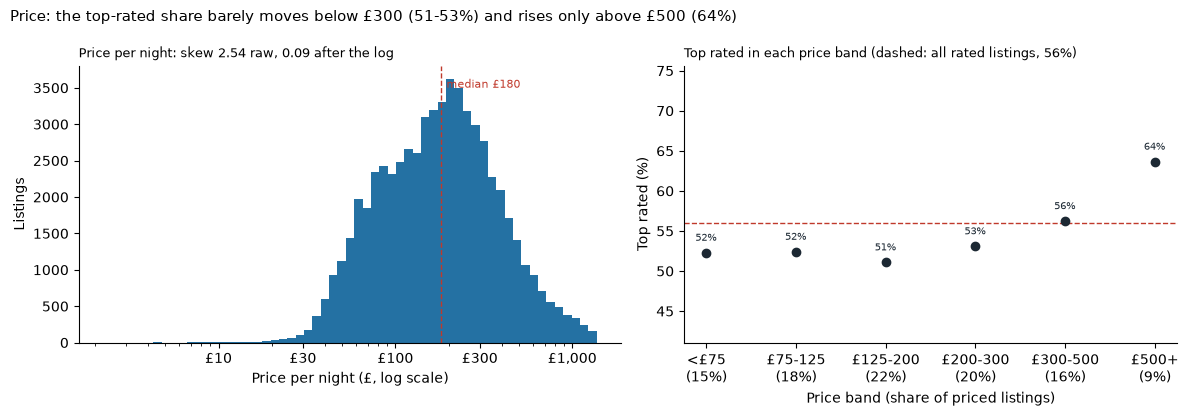

**Insight:** based on 62,238 priced listings, raw price has skew 2.54 and kurtosis 8.1 even after capping, and 3,963 listings (6%) sit above the upper IQR fence of £600. After the log transform, skew is 0.09 and kurtosis -0.11 (a normal distribution has 0 for both), the histogram is close to symmetric, and the fence count falls to 105.

**Top rating:** price is a weak signal on its own. From under £75 to £300 the top-rated share stays between 51% and 53%, below the 56% average; only listings above £500 clearly beat it (64%). Expensive listings also differ in size and location, so the multivariate part checks whether price matters once those are held fixed. Charging less does not, by itself, earn a higher rating.

**Decision:** price is analysed as **log(price)** from here on. The bivariate and multivariate parts should use `np.log(price_capped)`; raw £ values are only used for labels that readers need in pounds.

In [4]:
PRICE_BINS = [0, 75, 125, 200, 300, 500, np.inf]
PRICE_LABELS = ["<£75", "£75-125", "£125-200", "£200-300", "£300-500", "£500+"]


def prep_fig6(d):
    p = d["price_capped"].dropna()
    band = band_labels(d["price_capped"], PRICE_BINS, PRICE_LABELS)
    return dict(p=p, lp=np.log(p), band_share=labelled_bins(d["price_capped"], PRICE_BINS, PRICE_LABELS),
                band_rate=rate_by(band, d, PRICE_LABELS), base=top_rate(d))


def draw_fig6(v):
    p, lp, band_rate = v["p"], v["lp"], v["band_rate"]
    ticks = [10, 30, 100, 300, 1000]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.1, 1]})

    ax = axes[0]
    ax.hist(p, bins=np.logspace(np.log10(p.min()), np.log10(p.max()), 60), color=BLUE)
    ax.set_xscale("log")
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"£{t:,}" for t in ticks])
    ax.axvline(p.median(), color=RED, ls="--", lw=1)
    ax.text(p.median() * 1.08, ax.get_ylim()[1] * 0.92, f"median £{p.median():.0f}", fontsize=8, color=RED)
    ax.set_xlabel("Price per night (£, log scale)")
    ax.set_ylabel("Listings")
    ax.set_title(f"Price per night: skew {p.skew():.2f} raw, {lp.skew():.2f} after the log", loc="left", fontsize=9)
    clean_axes(ax)

    rate_dots(axes[1], with_share(band_rate, v["band_share"]), v["base"])
    axes[1].set_xlabel("Price band (share of priced listings)")
    axes[1].set_title(f"Top rated in each price band (dashed: all rated listings, {v['base']:.0f}%)", loc="left", fontsize=9)

    low = band_rate.iloc[:-2]
    fig.suptitle(f"Price: the top-rated share barely moves below £300 ({low.min():.0f}-{low.max():.0f}%) and rises only "
                 f"above £500 ({band_rate.iloc[-1]:.0f}%)", x=0.01, ha="left", fontsize=11)
    plt.tight_layout()
    return fig


v6 = prep_fig6(df)
p, lp, price_rate = v6["p"], v6["lp"], v6["band_rate"]
draw_fig6(v6).savefig("../figures/fig6_price_distribution.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** based on {len(p):,} priced listings, raw price has skew {p.skew():.2f} and kurtosis {p.kurt():.1f} even after "
    f"capping, and {n_outside(p):,} listings ({n_outside(p) / len(p) * 100:.0f}%) sit above the upper IQR fence of £{iqr_fences(p)[1]:.0f}. "
    f"After the log transform, skew is {lp.skew():.2f} and kurtosis {lp.kurt():.2f} (a normal distribution has 0 for both), "
    f"the histogram is close to symmetric, and the fence count falls to {n_outside(lp):,}.\n\n"
    f"**Top rating:** price is a weak signal on its own. From under £75 to £300 the top-rated share stays between "
    f"{price_rate.iloc[:-2].min():.0f}% and {price_rate.iloc[:-2].max():.0f}%, below the {v6['base']:.0f}% average; only listings above £500 "
    f"clearly beat it ({price_rate.iloc[-1]:.0f}%). Expensive listings also differ in size and location, so the multivariate part "
    f"checks whether price matters once those are held fixed. Charging less does not, by itself, earn a higher rating.\n\n"
    f"**Decision:** price is analysed as **log(price)** from here on. The bivariate and multivariate parts should use "
    f"`np.log(price_capped)`; raw £ values are only used for labels that readers need in pounds."))

## Figure 7: Property type, and the top-rated share of each
Left: share of listings for the 10 most common property types. Right: top-rated share of each; groups with fewer than 100 rated listings are marked "too few". Property types already carry the room type ("Entire ...", "Private room in ..."); room type itself is summarised in the insight.

Room type and property type are **context**: they are fixed for a given property. Room type is tested for significance in Figure 14.

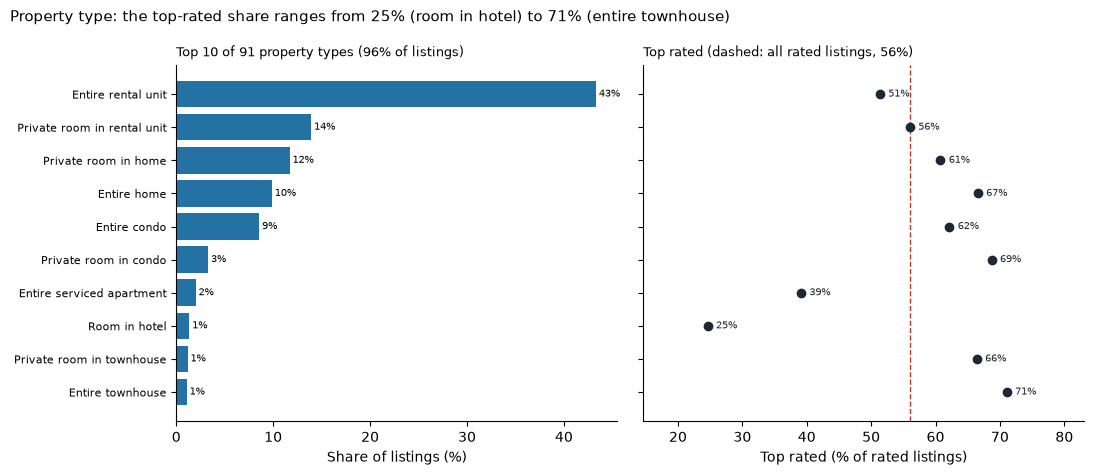

**Insight:** 66% of listings are entire homes and 33% private rooms; shared and hotel rooms (383 listings) are under 1% each and too small to compare reliably. **Top rating:** entire homes (55%) and private rooms (58%) are top rated at similar rates, so room type alone says little. Property type separates more: entire townhouse listings are top rated 71% of the time, room in hotel only 25%. `property_type` has a long tail of rare labels, so grouping it into a few categories is better for modeling.

In [5]:
def prep_fig7(d):
    room = (d["room_type"].value_counts(normalize=True) * 100).sort_values()
    top10 = (d["property_type"].value_counts(normalize=True) * 100).head(10).sort_values()
    return dict(room=room, top10=top10, n_prop=d["property_type"].nunique(),
                room_rate=rate_by(d["room_type"], d, room.index),
                prop_rate=rate_by(d["property_type"], d, top10.index), base=top_rate(d))


def draw_fig7(v):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
    share_and_rate(axes[0], axes[1], v["top10"], v["prop_rate"], v["base"], horizontal=True)
    axes[0].set_title(f"Top 10 of {v['n_prop']} property types ({v['top10'].sum():.0f}% of listings)", loc="left", fontsize=9)
    axes[0].set_xlabel("Share of listings (%)")
    axes[0].tick_params(axis="y", labelsize=8)
    axes[1].set_title(f"Top rated (dashed: all rated listings, {v['base']:.0f}%)", loc="left", fontsize=9)

    pr = v["prop_rate"]
    fig.suptitle(f"Property type: the top-rated share ranges from {pr.min():.0f}% ({pr.idxmin().lower()}) to "
                 f"{pr.max():.0f}% ({pr.idxmax().lower()})", x=0.01, ha="left", fontsize=11)
    plt.tight_layout()
    return fig


v7 = prep_fig7(df)
room, top10, room_rate, prop_rate = v7["room"], v7["top10"], v7["room_rate"], v7["prop_rate"]
draw_fig7(v7).savefig("../figures/fig7_room_property_type.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** {room['Entire home/apt']:.0f}% of listings are entire homes and {room['Private room']:.0f}% private rooms; shared and "
    f"hotel rooms ({(df['room_type'].isin(['Shared room', 'Hotel room'])).sum():,} listings) are under 1% each and too small to compare "
    f"reliably. **Top rating:** entire homes ({room_rate['Entire home/apt']:.0f}%) and private rooms ({room_rate['Private room']:.0f}%) are "
    f"top rated at similar rates, so room type alone says little. Property type separates more: {prop_rate.idxmax().lower()} listings "
    f"are top rated {prop_rate.max():.0f}% of the time, {prop_rate.idxmin().lower()} only {prop_rate.min():.0f}%. "
    f"`property_type` has a long tail of rare labels, so grouping it into a few categories is better for modeling."))

## Figure 8: Listing size, and the top-rated share by size
Guest capacity (`accommodates`, complete for all listings), with 8 or more grouped. Top: share of listings. Bottom: top-rated share at each capacity. Bedrooms, beds and bathrooms are summarised in the insight; bedrooms and beds are missing for a quarter to a third of listings.

Size is mostly **context**, but guest capacity is a setting the host can lower. Capacity is tested for significance in Figure 15.

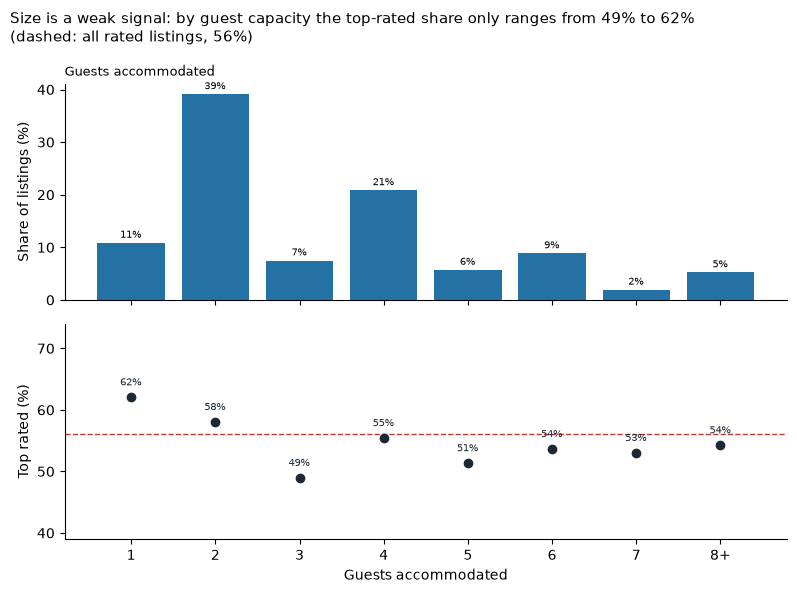

**Insight:** most listings are small (39% host two guests, 51% of known bedroom counts are one), and all four size variables are right-skewed, with a few large homes (up to 30 bedrooms and 50 beds). **Top rating:** size moves the top-rated share only a little. By guest capacity it ranges from 49% to 62%, highest for 1-guest listings. For the other size measures: bedrooms 53% to 63% (26% missing); beds 51% to 56% (35% missing); bathrooms 42% to 67% (0% missing). No size variable moves the share as much as host type or amenities (Figures 11 and 12), and `accommodates` (complete) is the most reliable size measure.

In [6]:
size_specs = [("accommodates", 8, "Guests accommodated"), ("bedrooms", 5, "Bedrooms"),
              ("beds", 6, "Beds"), ("bathrooms", 3, "Bathrooms")]


def prep_fig8(d):
    panels = []
    for col, cap, label in size_specs:
        share = bucket_counts(d[col], cap)
        panels.append((label, d[col].isna().mean() * 100, share, rate_by(cap_labels(d[col], cap), d, share.index)))
    return dict(panels=panels, acc=d["accommodates"].value_counts(normalize=True) * 100,
                bed1=(d["bedrooms"].dropna() == 1).mean() * 100, base=top_rate(d))


def draw_fig8(v):
    label, _, share, rate = v["panels"][0]
    fig, axes = plt.subplots(2, 1, figsize=(8, 6))
    share_and_rate(axes[0], axes[1], share, rate, v["base"])
    axes[0].set_title(label, loc="left", fontsize=9)
    axes[0].set_ylabel("Share of listings (%)")
    axes[1].set_xlabel(label)

    fig.suptitle(f"Size is a weak signal: by guest capacity the top-rated share only ranges from {rate.min():.0f}% to "
                 f"{rate.max():.0f}%\n(dashed: all rated listings, {v['base']:.0f}%)", x=0.01, ha="left", fontsize=11)
    plt.tight_layout()
    return fig


v8 = prep_fig8(df)
acc, cap_rate = v8["acc"], v8["panels"][0][3]
size_rates = {label: (miss, rate) for label, miss, _, rate in v8["panels"][1:]}
draw_fig8(v8).savefig("../figures/fig8_listing_size.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** most listings are small ({acc[2]:.0f}% host two guests, {v8['bed1']:.0f}% of known bedroom counts are one), and all four "
    f"size variables are right-skewed, with a few large homes (up to {df['bedrooms'].max():.0f} bedrooms and {df['beds'].max():.0f} beds). "
    f"**Top rating:** size moves the top-rated share only a little. By guest capacity it ranges from {cap_rate.min():.0f}% to "
    f"{cap_rate.max():.0f}%, highest for {cap_rate.idxmax()}-guest listings. For the other size measures: "
    + "; ".join(f"{label.lower()} {r.min():.0f}% to {r.max():.0f}% ({miss:.0f}% missing)" for label, (miss, r) in size_rates.items())
    + f". No size variable moves the share as much as host type or amenities (Figures 11 and 12), and `accommodates` (complete) "
    f"is the most reliable size measure."))

## Figure 9: Listings by borough, and the top-rated share by borough
Left: listings in each of London's 33 boroughs (`neighbourhood_cleansed`), with the five largest in blue. Right: share of rated listings in each borough that are top rated.

Location is **context** the model has to account for, not something a host can change. Tested for significance in Figure 16.

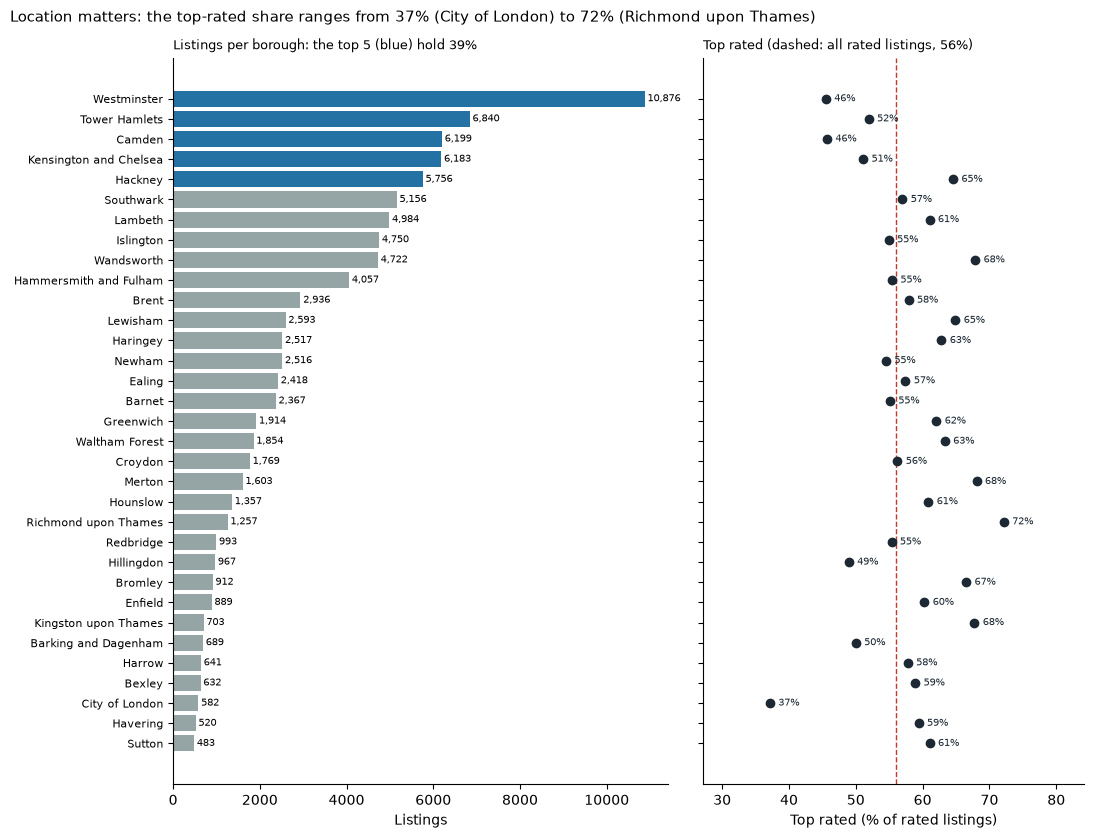

**Insight:** Westminster alone has 10,876 listings, about 23 times as many as Sutton (483). **Top rating:** 4 of the 5 busiest boroughs are below the 56% average (Westminster 46%), while quieter outer boroughs such as Richmond upon Thames lead (72%). Location cannot be changed, but the model needs it to compare like with like. Borough samples are very uneven, so outer-borough shares rest on small groups.

In [7]:
def prep_fig9(d):
    nb = d["neighbourhood_cleansed"].value_counts().sort_values()
    return dict(nb=nb, top5_share=nb.tail(5).sum() / nb.sum() * 100,
                rate=rate_by(d["neighbourhood_cleansed"], d, nb.index), base=top_rate(d))


def draw_fig9(v):
    nb, rate = v["nb"], v["rate"]
    fig, axes = plt.subplots(1, 2, figsize=(11, 8.5), gridspec_kw={"width_ratios": [1.3, 1]})
    ax = axes[0]
    bars = ax.barh(nb.index, nb.values, color=[BLUE if i >= len(nb) - 5 else GREY for i in range(len(nb))])
    ax.bar_label(bars, labels=[f"{x:,}" for x in nb.values], padding=2, fontsize=7)
    ax.set_xlabel("Listings")
    ax.tick_params(axis="y", labelsize=8)
    ax.set_title(f"Listings per borough: the top 5 (blue) hold {v['top5_share']:.0f}%", loc="left", fontsize=9)
    clean_axes(ax)
    rate_dots(axes[1], rate, v["base"], horizontal=True)
    axes[1].set_ylim(ax.get_ylim())
    axes[1].tick_params(labelleft=False)
    axes[1].set_title(f"Top rated (dashed: all rated listings, {v['base']:.0f}%)", loc="left", fontsize=9)

    fig.suptitle(f"Location matters: the top-rated share ranges from {rate.min():.0f}% ({rate.idxmin()}) to "
                 f"{rate.max():.0f}% ({rate.idxmax()})", x=0.01, ha="left", fontsize=11)
    plt.tight_layout()
    return fig


v9 = prep_fig9(df)
nb, top5_share, borough_rate = v9["nb"], v9["top5_share"], v9["rate"]
draw_fig9(v9).savefig("../figures/fig9_listings_by_borough.png", dpi=500, bbox_inches="tight")
plt.show()

busy_below = (borough_rate.tail(5) < v9["base"]).sum()
display(Markdown(
    f"**Insight:** {nb.index[-1]} alone has {nb.iloc[-1]:,} listings, about {nb.iloc[-1] / nb.iloc[0]:.0f} times "
    f"as many as {nb.index[0]} ({nb.iloc[0]:,}). **Top rating:** {busy_below} of the 5 busiest boroughs are below the "
    f"{v9['base']:.0f}% average ({nb.index[-1]} {borough_rate.iloc[-1]:.0f}%), while quieter outer boroughs such as "
    f"{borough_rate.idxmax()} lead ({borough_rate.max():.0f}%). Location cannot be changed, but the model needs it to compare like "
    f"with like. Borough samples are very uneven, so outer-borough shares rest on small groups."))

## Figure 10: Booking rules, and the top-rated share by minimum stay
Minimum stay in nights, grouped into bands. Top: share of listings. Bottom: top-rated share in each band. Availability in the next 365 days and the number of reviews are summarised in the insight.

Minimum nights is a **lever**; it is tested for significance in Figure 20. Listings with no reviews have no rating, so they are outside the comparison.

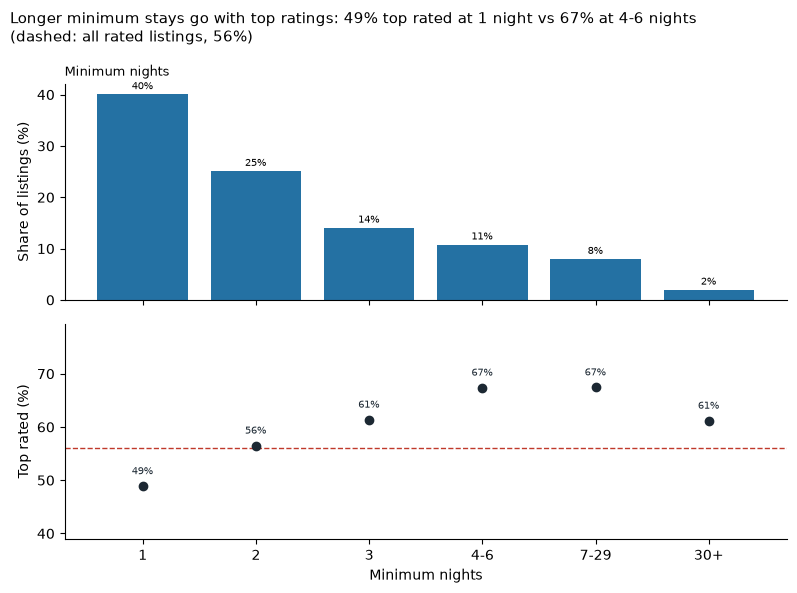

**Insight:** 79% of listings accept stays of 3 nights or fewer. **Top rating:** the top-rated share rises from 49% for 1-night minimums to 67% for 4-6 nights, a 19-point gap and one of the few levers a host can change today.

**Activity:** many listings look inactive: 24% have no reviews and 29% have no open days in the next year (fully booked or blocked by the host; the data cannot tell these apart). Listings open most of the year (271-365 days) are top rated least often (48%, against 62% for those with no open days). Listings with no reviews have no rating, so the model is trained on the 70,708 rated listings only. Reviews are extremely skewed (median 5, max 1,959, skew 7), so review counts need a log scale.

In [8]:
NIGHT_BINS, NIGHT_LABELS = [0, 1, 2, 3, 6, 29, np.inf], ["1", "2", "3", "4-6", "7-29", "30+"]
AVAIL_BINS, AVAIL_LABELS = [-1, 0, 90, 180, 270, 365], ["0", "1-90", "91-180", "181-270", "271-365"]
REV_BINS, REV_LABELS = [-1, 0, 4, 19, 49, 99, np.inf], ["0", "1-4", "5-19", "20-49", "50-99", "100+"]
activity_specs = [("minimum_nights", NIGHT_BINS, NIGHT_LABELS, "Minimum nights"),
                  ("availability_365", AVAIL_BINS, AVAIL_LABELS, "Days available, next 365"),
                  ("number_of_reviews", REV_BINS, REV_LABELS, "Number of reviews")]


def prep_fig10(d):
    panels = [(title, labelled_bins(d[col], bins, labels), rate_by(band_labels(d[col], bins, labels), d, labels))
              for col, bins, labels, title in activity_specs]
    return dict(panels=panels, base=top_rate(d))


def draw_fig10(v):
    title, share, rate = v["panels"][0]
    fig, axes = plt.subplots(2, 1, figsize=(8, 6))
    share_and_rate(axes[0], axes[1], share, rate, v["base"])
    axes[0].set_title(title, loc="left", fontsize=9)
    axes[0].set_ylabel("Share of listings (%)")
    axes[1].set_xlabel(title)

    fig.suptitle(f"Longer minimum stays go with top ratings: {rate['1']:.0f}% top rated at 1 night vs {rate['4-6']:.0f}% "
                 f"at 4-6 nights\n(dashed: all rated listings, {v['base']:.0f}%)", x=0.01, ha="left", fontsize=11)
    plt.tight_layout()
    return fig


v10 = prep_fig10(df)
(_, min_n, nights_rate), (_, avail, avail_rate), (_, revs, revs_rate) = v10["panels"]
draw_fig10(v10).savefig("../figures/fig10_booking_activity.png", dpi=500, bbox_inches="tight")
plt.show()

nr = df["number_of_reviews"]
display(Markdown(
    f"**Insight:** {(df['minimum_nights'] <= 3).mean() * 100:.0f}% of listings accept stays of 3 nights or fewer. "
    f"**Top rating:** the top-rated share rises from {nights_rate['1']:.0f}% for 1-night minimums to {nights_rate['4-6']:.0f}% for 4-6 nights, "
    f"a {nights_rate['4-6'] - nights_rate['1']:.0f}-point gap and one of the few levers a host can change today.\n\n"
    f"**Activity:** many listings look inactive: {revs['0']:.0f}% have no reviews and {avail['0']:.0f}% have no open days in the next year "
    f"(fully booked or blocked by the host; the data cannot tell these apart). Listings open most of the year (271-365 days) are top "
    f"rated least often ({avail_rate['271-365']:.0f}%, against {avail_rate['0']:.0f}% for those with no open days). Listings with no reviews "
    f"have no rating, so the model is trained on the {len(rated):,} rated listings only. Reviews are extremely skewed (median "
    f"{nr.median():.0f}, max {nr.max():,}, skew {nr.skew():.0f}), so review counts need a log scale."))

## Figure 11: Hosts, and the top-rated share by host type
How many listings each host runs. Top: share of listings. Bottom: top-rated share for each host size. Host tenure is summarised in the insight. Host profile flags are not plotted: identity verification and profile pictures are near-universal, and Superhost is leakage (it depends on the rating).

Host type and tenure are **context** in the short term, but they show who runs the listings. Tested for significance in Figures 17 and 18.

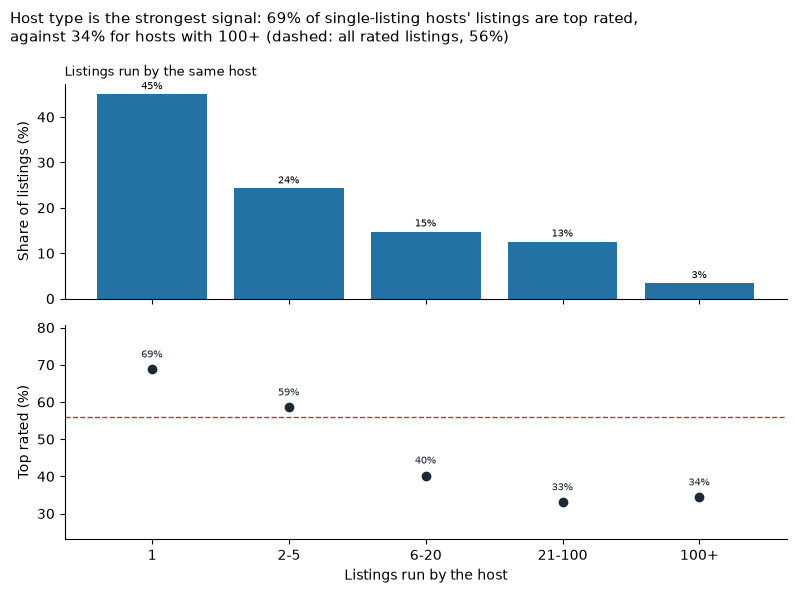

**Insight:** 45% of listings come from single-listing hosts, while 16% come from hosts with more than 20 (the largest runs 501 listings). **Top rating:** the top-rated share falls steadily with host size, from 69% for single-listing hosts to 33% for hosts with more than 20, the biggest gap in this part. Professionally managed listings are top rated far less often, so host type is a key control for the model, and a reminder that personal hosting goes with top ratings. Host tenure (median 6 years) has two peaks, about 2 and 9 years, but no clear trend in the top-rated share (50% to 63%). Identity verification (98%) and profile pictures (95%) are near-universal, so they carry little information for the model.

In [9]:
HOST_BINS, HOST_LABELS = [0, 1, 5, 20, 100, np.inf], ["1", "2-5", "6-20", "21-100", "100+"]


def prep_fig11(d):
    hosts = d["calculated_host_listings_count"]
    ten = d["hosts_time_as_host_years"]
    ten_share = bucket_counts(ten, 14)
    return dict(hl=labelled_bins(hosts, HOST_BINS, HOST_LABELS),
                hl_rate=rate_by(band_labels(hosts, HOST_BINS, HOST_LABELS), d, HOST_LABELS),
                ten_share=ten_share, ten_rate=rate_by(cap_labels(ten, 14), d, ten_share.index),
                ten_median=ten.median(), base=top_rate(d))


def draw_fig11(v):
    fig, axes = plt.subplots(2, 1, figsize=(8, 6))
    share_and_rate(axes[0], axes[1], v["hl"], v["hl_rate"], v["base"])
    axes[0].set_title("Listings run by the same host", loc="left", fontsize=9)
    axes[0].set_ylabel("Share of listings (%)")
    axes[1].set_xlabel("Listings run by the host")

    hr = v["hl_rate"]
    fig.suptitle(f"Host type is the strongest signal: {hr['1']:.0f}% of single-listing hosts' listings are top rated,\n"
                 f"against {hr['100+']:.0f}% for hosts with 100+ (dashed: all rated listings, {v['base']:.0f}%)",
                 x=0.01, ha="left", fontsize=11)
    plt.tight_layout()
    return fig


v11 = prep_fig11(df)
hl, host_rate, ten_rate = v11["hl"], v11["hl_rate"], v11["ten_rate"]
draw_fig11(v11).savefig("../figures/fig11_hosts.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** {hl['1']:.0f}% of listings come from single-listing hosts, while {hl['21-100'] + hl['100+']:.0f}% come from hosts "
    f"with more than 20 (the largest runs {df['calculated_host_listings_count'].max()} listings). **Top rating:** the top-rated share falls "
    f"steadily with host size, from {host_rate['1']:.0f}% for single-listing hosts to {host_rate.min():.0f}% for hosts with more than 20, "
    f"the biggest gap in this part. Professionally managed listings are top rated far less often, so host type is a key control for "
    f"the model, and a reminder that personal hosting goes with top ratings. Host tenure (median {v11['ten_median']:.0f} years) has two peaks, about 2 and 9 years, but no clear "
    f"trend in the top-rated share ({ten_rate.min():.0f}% to {ten_rate.max():.0f}%). Identity verification "
    f"({(df['host_identity_verified'] == 't').mean() * 100:.0f}%) and profile pictures ({(df['host_has_profile_pic'] == 't').mean() * 100:.0f}%) "
    f"are near-universal, so they carry little information for the model."))

## Figure 12: Amenities, and which ones go with a top rating
Left: top-rated share by the number of amenities listed, with the band's share of listings in brackets. Right: of the amenities on at least 10% of rated listings, the 15 with the biggest gap in top-rated share between listings with and without them. `amenities` is stored as a JSON list in text.

Amenities are the most direct **lever**: a host can add one today. The count is tested for significance in Figure 19.

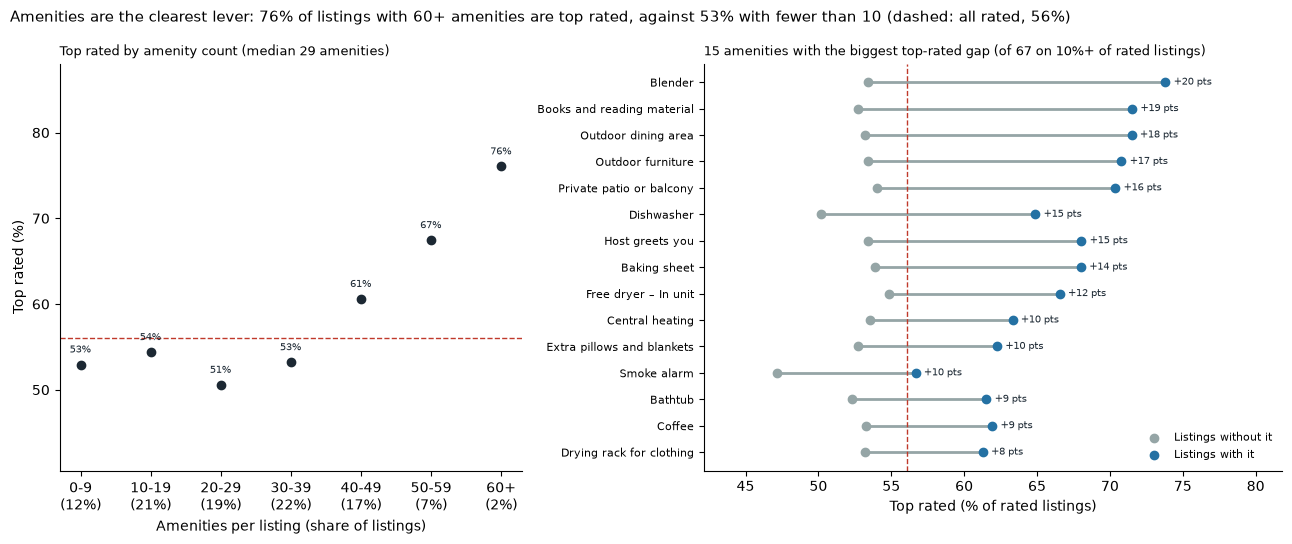

**Insight:** listings advertise a median of 29 amenities (from 0 to 103). **Top rating:** up to 39 amenities the top-rated share stays between 51% and 54%, then climbs to 76% at 60+. Of the 67 amenities on at least 10% of rated listings, blender shows the biggest gap (74% top rated with it vs 53% without). The top 15 are mostly homely extras (kitchen tools, outdoor space, books) rather than basics. Some common items go the other way: listings with heating are top rated less often (53% vs 61%), possibly because such items are listed more by professionally managed listings (Figure 11). These are associations, not effects: the multivariate part checks whether amenities still matter once host type and location are held fixed. The 9,625 distinct names include many free-text variants, so rarer amenities need grouping before use.

In [10]:
AMEN_BINS = [-1, 9, 19, 29, 39, 49, 59, np.inf]
AMEN_LABELS = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60+"]


def prep_fig12(d):
    amen = d["amenities"].apply(lambda s: json.loads(s) if isinstance(s, str) else [])
    n_amen = amen.str.len()
    # Top-rated share with and without each amenity, for amenities on at least 10% of rated listings
    y = d["top_rated"].dropna()
    ex = amen[y.index].apply(set).explode().dropna()
    g = y.reindex(ex.index).groupby(ex.values).agg(["size", "sum"])
    g = g[g["size"] >= 0.1 * len(y)]
    gap = pd.DataFrame({"with": g["sum"] / g["size"] * 100,
                        "without": (y.sum() - g["sum"]) / (len(y) - g["size"]) * 100})
    gap["gap"] = gap["with"] - gap["without"]
    return dict(amen=amen, n_amen=n_amen, band_share=labelled_bins(n_amen, AMEN_BINS, AMEN_LABELS),
                band_rate=rate_by(band_labels(n_amen, AMEN_BINS, AMEN_LABELS), d, AMEN_LABELS),
                gap=gap.sort_values("gap"), base=top_rate(d))


def draw_fig12(v):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [1, 1.25]})
    ax_rate, ax_gap = axes
    rate_dots(ax_rate, with_share(v["band_rate"], v["band_share"]), v["base"])
    ax_rate.set_xlabel("Amenities per listing (share of listings)")
    ax_rate.set_title(f"Top rated by amenity count (median {v['n_amen'].median():.0f} amenities)", loc="left", fontsize=9)

    top = v["gap"].tail(15)
    pos = np.arange(len(top))
    ax_gap.hlines(pos, top["without"], top["with"], color=GREY, lw=2, zorder=1)
    ax_gap.scatter(top["without"], pos, s=36, color=GREY, zorder=2, label="Listings without it")
    ax_gap.scatter(top["with"], pos, s=36, color=BLUE, zorder=2, label="Listings with it")
    for i, (w, gp) in enumerate(zip(top["with"], top["gap"])):
        ax_gap.annotate(f"+{gp:.0f} pts", (w, i), xytext=(6, 0), textcoords="offset points", va="center", fontsize=7, color=INK)
    ax_gap.axvline(v["base"], color=RED, ls="--", lw=1)
    ax_gap.set_yticks(pos, top.index)
    ax_gap.tick_params(axis="y", labelsize=8)
    ax_gap.set_xlim(top["without"].min() - 5, top["with"].max() + 8)
    ax_gap.set_xlabel("Top rated (% of rated listings)")
    ax_gap.set_title(f"15 amenities with the biggest top-rated gap (of {len(v['gap'])} on 10%+ of rated listings)",
                     loc="left", fontsize=9)
    ax_gap.legend(loc="lower right", fontsize=8, frameon=False)
    clean_axes(ax_gap)

    br = v["band_rate"]
    fig.suptitle(f"Amenities are the clearest lever: {br['60+']:.0f}% of listings with 60+ amenities are top rated, "
                 f"against {br['0-9']:.0f}% with fewer than 10 (dashed: all rated, {v['base']:.0f}%)", x=0.01, ha="left", fontsize=11)
    plt.tight_layout()
    return fig


v12 = prep_fig12(df)
amen, n_amen, amen_rate, amen_gap = v12["amen"], v12["n_amen"], v12["band_rate"], v12["gap"]
draw_fig12(v12).savefig("../figures/fig12_amenities.png", dpi=500, bbox_inches="tight")
plt.show()

best, worst = amen_gap.iloc[-1], amen_gap.iloc[0]
display(Markdown(
    f"**Insight:** listings advertise a median of {n_amen.median():.0f} amenities (from {n_amen.min()} to {n_amen.max()}). "
    f"**Top rating:** up to 39 amenities the top-rated share stays between {amen_rate.iloc[:4].min():.0f}% and "
    f"{amen_rate.iloc[:4].max():.0f}%, then climbs to {amen_rate['60+']:.0f}% at 60+. Of the {len(amen_gap)} amenities on at least 10% "
    f"of rated listings, {amen_gap.index[-1].lower()} shows the biggest gap ({best['with']:.0f}% top rated with it vs "
    f"{best['without']:.0f}% without). The top 15 are mostly homely extras (kitchen tools, outdoor space, books) rather than basics. "
    f"Some common items go the other way: listings with {amen_gap.index[0].lower()} are top rated less often ({worst['with']:.0f}% vs "
    f"{worst['without']:.0f}%), possibly because such items are listed more by professionally managed listings (Figure 11). "
    f"These are associations, not effects: the multivariate part checks whether amenities still matter once host type and location "
    f"are held fixed. The {amen.explode().nunique():,} distinct names include many free-text variants, so rarer amenities need "
    f"grouping before use."))

## Step 2: Outlier verdicts
The IQR fences in Step 1 flag thousands of listings, but most are the normal long tail. This step looks at the most extreme values one by one and decides whether each is **real**, a **data error** or a **policy value**, and what is done with it.

In [11]:
def top_row(col):
    return df.loc[df[col].idxmax()]

pr_max, bed_max, bath_max = top_row("price"), top_row("bedrooms"), top_row("bathrooms")
beds_max, rev_max, host_max = top_row("beds"), top_row("number_of_reviews"), top_row("calculated_host_listings_count")
mn = df["minimum_nights"]
hl_col = df["calculated_host_listings_count"]

display(Markdown(f"""
| Variable | Most extreme value | How many listings | Verdict | Action |
|---|---|---|---|---|
| `price` | £{pr_max['price']:,.0f} a night ({pr_max['room_type'].lower()}) | {(df['price'] > 5000).sum()} above £5,000; {(df['price'] > df['price_capped']).sum()} above the 99th-percentile cap | **Data error** above about £5,000 (placeholder or typo); real luxury listings between the cap and £5,000 | Capped at £{df['price_capped'].max():,.0f} in cleaning (`price_capped`), then log-transformed |
| `bedrooms` | {bed_max['bedrooms']:.0f} bedrooms for a {bed_max['accommodates']:.0f}-guest {bed_max['room_type'].lower()} ("{bed_max['name']}") | {(df['bedrooms'] >= 10).sum()} with 10 or more | **Data error**: the building's room count was entered, not the listing's | Kept, grouped into 5+ in charts and flagged (`size_extreme`) in cleaning; `accommodates` is the main size measure |
| `beds` | {beds_max['beds']:.0f} beds in a {beds_max['room_type'].lower()} for {beds_max['accommodates']:.0f} guests | {(df['beds'] > 2 * df['accommodates']).sum()} with more than 2 beds per guest | **Mixed**: real dormitory beds in hostels; errors where a private or hotel room lists dozens | Same as bedrooms: grouped into 6+ and flagged |
| `bathrooms` | {bath_max['bathrooms']:.0f} bathrooms for a {bath_max['accommodates']:.0f}-guest {bath_max['room_type'].lower()} | {(df['bathrooms'] >= 10).sum()} with 10 or more | **Data error**: building-level count | Grouped into 3+ and flagged |
| `minimum_nights` | {mn.max():,.0f} nights | {(mn > 365).sum()} above a year | **Policy value**: 1,125 is Airbnb's maximum setting, used to block bookings, not a real stay length | Capped at 365 (`minimum_nights_capped`) in cleaning; shown as a 30+ band |
| `number_of_reviews` | {rev_max['number_of_reviews']:,} reviews ({rev_max['reviews_per_month']:.0f} a month, {rev_max['room_type'].lower()}) | {n_outside(df['number_of_reviews']):,} above the IQR fence | **Real**: hotel-style rooms with very high turnover | Kept; log scale or bands |
| `calculated_host_listings_count` | {host_max['calculated_host_listings_count']} listings from one host | {(hl_col > 100).sum():,} listings belong to hosts with 100+ | **Real**: property-management companies | Kept; shown in bands, and host type is tested in the bivariate part |
| `review_scores_rating` | lowest score {rt.min():.1f} | {n_outside(rt):,} below the lower IQR fence ({iqr_fences(rt)[0]:.2f}) | **Real**: genuine guest scores | Kept; they belong to the below-4.8 class |
"""))
display(Markdown(
    "**Insight:** only the size counts and the extreme prices are errors, and both come from whole buildings or placeholders. "
    "Nothing is deleted: errors are capped or flagged so the listing stays in the sample, and real extremes "
    "(review counts, large hosts, low ratings) are kept because they describe real London listings."))


| Variable | Most extreme value | How many listings | Verdict | Action |
|---|---|---|---|---|
| `price` | £527,524 a night (entire home/apt) | 100 above £5,000; 623 above the 99th-percentile cap | **Data error** above about £5,000 (placeholder or typo); real luxury listings between the cap and £5,000 | Capped at £1,373 in cleaning (`price_capped`), then log-transformed |
| `bedrooms` | 30 bedrooms for a 1-guest private room ("King's College Stamford Street Apartments") | 31 with 10 or more | **Data error**: the building's room count was entered, not the listing's | Kept, grouped into 5+ in charts and flagged (`size_extreme`) in cleaning; `accommodates` is the main size measure |
| `beds` | 50 beds in a shared room for 16 guests | 156 with more than 2 beds per guest | **Mixed**: real dormitory beds in hostels; errors where a private or hotel room lists dozens | Same as bedrooms: grouped into 6+ and flagged |
| `bathrooms` | 30 bathrooms for a 2-guest private room | 28 with 10 or more | **Data error**: building-level count | Grouped into 3+ and flagged |
| `minimum_nights` | 1,125 nights | 25 above a year | **Policy value**: 1,125 is Airbnb's maximum setting, used to block bookings, not a real stay length | Capped at 365 (`minimum_nights_capped`) in cleaning; shown as a 30+ band |
| `number_of_reviews` | 1,959 reviews (32 a month, private room) | 10,574 above the IQR fence | **Real**: hotel-style rooms with very high turnover | Kept; log scale or bands |
| `calculated_host_listings_count` | 501 listings from one host | 3,148 listings belong to hosts with 100+ | **Real**: property-management companies | Kept; shown in bands, and host type is tested in the bivariate part |
| `review_scores_rating` | lowest score 1.0 | 2,840 below the lower IQR fence (4.00) | **Real**: genuine guest scores | Kept; they belong to the below-4.8 class |


**Insight:** only the size counts and the extreme prices are errors, and both come from whole buildings or placeholders. Nothing is deleted: errors are capped or flagged so the listing stays in the sample, and real extremes (review counts, large hosts, low ratings) are kept because they describe real London listings.

## Step 3: Missing data, mean or median
Price, bedrooms, beds and bathrooms have missing values. Before any filling, compare mean and median for each, overall and by room type.

In [12]:
miss_cols = ["price_capped", "bedrooms", "beds", "bathrooms"]
mm = pd.DataFrame({"missing_pct": df[miss_cols].isna().mean() * 100,
                   "mean": df[miss_cols].mean(),
                   "median": df[miss_cols].median(),
                   "skew": df[miss_cols].skew()})
mm["mean_above_median_pct"] = (mm["mean"] - mm["median"]) / mm["median"] * 100
display(mm.round(2))

by_room = df.groupby("room_type")[miss_cols].median()
display(by_room)

display(Markdown(
    f"**Decision: fill with the median, within each room type.** All four columns are right-skewed "
    f"(skew {mm['skew'].min():.1f} to {mm['skew'].max():.1f}), so the mean is pulled up by the long tail: mean price is "
    f"£{mm.at['price_capped', 'mean']:.0f} against a median of £{mm.at['price_capped', 'median']:.0f} "
    f"({mm.at['price_capped', 'mean_above_median_pct']:.0f}% higher), and mean bedrooms is {mm.at['bedrooms', 'mean']:.2f} against {mm.at['bedrooms', 'median']:.0f}. "
    f"Filling {mm.at['price_capped', 'missing_pct']:.0f}% of listings with the mean would push them toward luxury prices. "
    f"Medians also differ by room type (entire home £{by_room.at['Entire home/apt', 'price_capped']:.0f} vs private room "
    f"£{by_room.at['Private room', 'price_capped']:.0f}), so one overall median would overstate private rooms. "
    f"This matches `01_cleaning.ipynb`, which writes the filled values to new `*_imp` columns and adds `*_missing` flags. "
    f"The charts in this notebook use observed values only."))

,missing_pct,mean,median,skew,mean_above_median_pct
price_capped,32.81,244.37,180.0,2.54,35.76
bedrooms,25.89,1.77,1.0,2.92,76.79
beds,35.06,2.02,2.0,3.38,1.05
bathrooms,0.14,1.33,1.0,4.79,33.19


,price_capped,bedrooms,beds,bathrooms
room_type,,,,
Entire home/apt,239.50,2.0,2.0,1.0
Hotel room,156.00,1.0,1.0,1.0
Private room,82.34,1.0,1.0,1.0
Shared room,44.00,1.0,2.0,1.0


**Decision: fill with the median, within each room type.** All four columns are right-skewed (skew 2.5 to 4.8), so the mean is pulled up by the long tail: mean price is £244 against a median of £180 (36% higher), and mean bedrooms is 1.77 against 1. Filling 33% of listings with the mean would push them toward luxury prices. Medians also differ by room type (entire home £240 vs private room £82), so one overall median would overstate private rooms. This matches `01_cleaning.ipynb`, which writes the filled values to new `*_imp` columns and adds `*_missing` flags. The charts in this notebook use observed values only.

## Step 4: Decision table
Every choice made in this part, and why. Cleaning decisions are in `01_cleaning.ipynb`; this table only covers how each variable was analysed and shown.

In [13]:
sk = lambda c: df[c].skew()
display(Markdown(f"""
| Column / issue | Decision | Because |
|---|---|---|
| `review_scores_rating` | Plotted for the {len(rated):,} rated listings only; x-axis starts at 3.5 | {df['review_scores_rating'].isna().sum():,} unrated listings have no score; the {(rt < 3.5).mean() * 100:.1f}% below 3.5 would flatten the chart, so their share is stated in the axis label |
| `top_rated` | Shown as class shares; no resampling suggested | Classes are close to balanced ({target_share.iloc[1]:.0f}% vs {target_share.iloc[0]:.0f}%) |
| Price | Used `price_capped`; **log(price) chosen** for all later parts | Raw skew {p.skew():.2f} and kurtosis {p.kurt():.1f}; after the log, skew {lp.skew():.2f} and kurtosis {lp.kurt():.2f}, and the log histogram is close to symmetric |
| Price missing ({df['price'].isna().mean() * 100:.0f}%) | Left out of price charts; filled with the room-type median only as a model input, with a missing flag | These listings mostly cannot be booked, so observed prices describe the market; the flag lets the model separate them |
| `price_quote_price_per_night`, `price_quote_total_price` | Not analysed separately | Per-night quote equals `price` for all {df['price'].notna().sum():,} priced listings |
| `estimated_revenue_l365d` | Not analysed | Derived from price and estimated occupancy, so it repeats information already shown |
| `room_type` | All 4 categories kept; shares and top-rated shares given in the Figure 7 insight | Shared and hotel rooms are only {(df['room_type'].isin(['Shared room', 'Hotel room'])).sum():,} listings, so they are flagged as too small to compare, not dropped |
| `property_type` | Top 10 of {df['property_type'].nunique()} shown; grouping recommended | The top 10 cover {top10.sum():.0f}% of listings; the rest is a long tail of rare labels |
| `accommodates`, `bedrooms`, `beds`, `bathrooms` | Guest capacity plotted (8+ grouped); bedrooms (5+), beds (6+) and bathrooms (3+) grouped the same way and summarised in the Figure 8 insight | Rare extremes (up to {df['bedrooms'].max():.0f} bedrooms, {df['beds'].max():.0f} beds) would stretch the axis |
| `bedrooms` ({df['bedrooms'].isna().mean() * 100:.0f}% missing), `beds` ({df['beds'].isna().mean() * 100:.0f}% missing) | Missing share stated in the Figure 8 insight; filled with the **median by room type** for modeling | Skewed, so the mean overstates the typical listing (Step 3); `accommodates` is complete and used as the main size measure |
| `neighbourhood_cleansed` | All {nb.size} boroughs shown, top 5 highlighted | Only {nb.size} categories, so nothing needs grouping; the uneven spread is itself the finding |
| `latitude`, `longitude` | Not plotted here | Location is covered by borough; point maps belong in the dashboard |
| `minimum_nights` | Grouped into bands (1, 2, 3, 4-6, 7-29, 30+) | Skew {sk('minimum_nights'):.0f}; max {df['minimum_nights'].max():,.0f} nights |
| `availability_365` | Grouped into bands; share with 0 days and top-rated share by band stated in the Figure 10 insight | {(df['availability_365'] == 0).mean() * 100:.0f}% have 0 days, which can mean fully booked or blocked; the data cannot tell these apart |
| `number_of_reviews` | Share with no reviews and skew stated in the Figure 10 insight | Skew {sk('number_of_reviews'):.0f}; median {nr.median():.0f} but max {nr.max():,} |
| `calculated_host_listings_count` used, `host_listings_count` not | Used the count from this snapshot | It is complete and counts London listings in this data; `host_listings_count` matches it for only {(df['host_listings_count'] == df['calculated_host_listings_count']).mean() * 100:.0f}% of listings |
| `hosts_time_as_host_years` | Used years; months column ignored; summarised in the Figure 11 insight | The months column only holds the remainder (0-11), so years alone shows the distribution |
| `host_identity_verified`, `host_has_profile_pic` | Not plotted; shares stated in the Figure 11 insight and flagged as low information | Near-universal ({(df['host_identity_verified'] == 't').mean() * 100:.0f}% and {(df['host_has_profile_pic'] == 't').mean() * 100:.0f}%) |
| `host_is_superhost` | Not plotted | Tied to the rating (leakage), so it must not be a model feature |
| Review sub-scores (`review_scores_accuracy` etc.) | Not plotted | Leakage; they are parts of the overall rating |
| Host response rate, acceptance rate, response time | Not analysed | Completely empty in this snapshot (dropped in cleaning) |
| `amenities` | Parsed from JSON text; top-rated share by count shown, and the 15 amenities (of those on 10%+ of rated listings) with the biggest top-rated gap | {amen.explode().nunique():,} distinct free-text names; individual amenities need grouping before use, and rare ones give unstable shares |
| Top-rated share per group | Shown next to every distribution, against the share for all rated listings; groups with fewer than 100 rated listings left blank | Links each variable to the top rating; small groups give unstable shares. Formal tests are left to the bivariate part |
| Kurtosis and IQR outliers | Computed for every numeric variable (Step 1) | Fence counts alone are not used to drop data, because most flagged points are the long tail of skewed variables |
| Extreme values | Verdict per variable (Step 2): errors capped or flagged, real extremes kept | No listing is deleted; capping keeps the sample while removing impossible values |
| `name`, `description`, `host_about` | Not analysed | Free text needs text processing, which is outside univariate EDA |
"""))


| Column / issue | Decision | Because |
|---|---|---|
| `review_scores_rating` | Plotted for the 70,708 rated listings only; x-axis starts at 3.5 | 21,927 unrated listings have no score; the 2.4% below 3.5 would flatten the chart, so their share is stated in the axis label |
| `top_rated` | Shown as class shares; no resampling suggested | Classes are close to balanced (56% vs 44%) |
| Price | Used `price_capped`; **log(price) chosen** for all later parts | Raw skew 2.54 and kurtosis 8.1; after the log, skew 0.09 and kurtosis -0.11, and the log histogram is close to symmetric |
| Price missing (33%) | Left out of price charts; filled with the room-type median only as a model input, with a missing flag | These listings mostly cannot be booked, so observed prices describe the market; the flag lets the model separate them |
| `price_quote_price_per_night`, `price_quote_total_price` | Not analysed separately | Per-night quote equals `price` for all 62,238 priced listings |
| `estimated_revenue_l365d` | Not analysed | Derived from price and estimated occupancy, so it repeats information already shown |
| `room_type` | All 4 categories kept; shares and top-rated shares given in the Figure 7 insight | Shared and hotel rooms are only 383 listings, so they are flagged as too small to compare, not dropped |
| `property_type` | Top 10 of 91 shown; grouping recommended | The top 10 cover 96% of listings; the rest is a long tail of rare labels |
| `accommodates`, `bedrooms`, `beds`, `bathrooms` | Guest capacity plotted (8+ grouped); bedrooms (5+), beds (6+) and bathrooms (3+) grouped the same way and summarised in the Figure 8 insight | Rare extremes (up to 30 bedrooms, 50 beds) would stretch the axis |
| `bedrooms` (26% missing), `beds` (35% missing) | Missing share stated in the Figure 8 insight; filled with the **median by room type** for modeling | Skewed, so the mean overstates the typical listing (Step 3); `accommodates` is complete and used as the main size measure |
| `neighbourhood_cleansed` | All 33 boroughs shown, top 5 highlighted | Only 33 categories, so nothing needs grouping; the uneven spread is itself the finding |
| `latitude`, `longitude` | Not plotted here | Location is covered by borough; point maps belong in the dashboard |
| `minimum_nights` | Grouped into bands (1, 2, 3, 4-6, 7-29, 30+) | Skew 26; max 1,125 nights |
| `availability_365` | Grouped into bands; share with 0 days and top-rated share by band stated in the Figure 10 insight | 29% have 0 days, which can mean fully booked or blocked; the data cannot tell these apart |
| `number_of_reviews` | Share with no reviews and skew stated in the Figure 10 insight | Skew 7; median 5 but max 1,959 |
| `calculated_host_listings_count` used, `host_listings_count` not | Used the count from this snapshot | It is complete and counts London listings in this data; `host_listings_count` matches it for only 74% of listings |
| `hosts_time_as_host_years` | Used years; months column ignored; summarised in the Figure 11 insight | The months column only holds the remainder (0-11), so years alone shows the distribution |
| `host_identity_verified`, `host_has_profile_pic` | Not plotted; shares stated in the Figure 11 insight and flagged as low information | Near-universal (98% and 95%) |
| `host_is_superhost` | Not plotted | Tied to the rating (leakage), so it must not be a model feature |
| Review sub-scores (`review_scores_accuracy` etc.) | Not plotted | Leakage; they are parts of the overall rating |
| Host response rate, acceptance rate, response time | Not analysed | Completely empty in this snapshot (dropped in cleaning) |
| `amenities` | Parsed from JSON text; top-rated share by count shown, and the 15 amenities (of those on 10%+ of rated listings) with the biggest top-rated gap | 9,625 distinct free-text names; individual amenities need grouping before use, and rare ones give unstable shares |
| Top-rated share per group | Shown next to every distribution, against the share for all rated listings; groups with fewer than 100 rated listings left blank | Links each variable to the top rating; small groups give unstable shares. Formal tests are left to the bivariate part |
| Kurtosis and IQR outliers | Computed for every numeric variable (Step 1) | Fence counts alone are not used to drop data, because most flagged points are the long tail of skewed variables |
| Extreme values | Verdict per variable (Step 2): errors capped or flagged, real extremes kept | No listing is deleted; capping keeps the sample while removing impossible values |
| `name`, `description`, `host_about` | Not analysed | Free text needs text processing, which is outside univariate EDA |


## Step 5: Key takeaways for the next parts

In [14]:
base = top_rate(df)
display(Markdown(f"""
- **Target:** ratings are bunched at the top (median {rt.median():.2f}); the 4.8 cut gives balanced classes ({target_share.iloc[1]:.0f}% top rated).
- **Use log price:** raw price has skew {p.skew():.2f}; log price has skew {lp.skew():.2f}. Number of reviews, minimum nights and host listing count also have long right tails, so use log scales or bands.
- **Outliers:** extreme bedrooms, beds, bathrooms and prices above about £5,000 are data errors (capped or flagged); review counts, large hosts and low ratings are real and kept.
- **Sparse categories:** shared and hotel rooms, rare property types and small outer boroughs have few listings. Group them before comparing.
- **Low-information features:** identity verification and profile pictures are near-universal.
- **Missing data:** price ({df['price'].isna().mean() * 100:.0f}%), bedrooms ({df['bedrooms'].isna().mean() * 100:.0f}%) and beds ({df['beds'].isna().mean() * 100:.0f}%) are filled with room-type medians, not means, with a missing flag kept.

**What goes with a top rating, and what a host can change** (share of rated listings that are top rated, across the groups of each variable; {base:.0f}% overall):

| Variable | Host can change it? | Top-rated share across groups | Figure here / test in Part 3 |
|---|---|---|---|
| Host type | No | {host_rate['1']:.0f}% (single-listing hosts) to {host_rate.min():.0f}% (hosts with 20+) | 11 / 17 |
| Amenities | **Yes, today** | {amen_rate['0-9']:.0f}% (0-9 amenities) to {amen_rate['60+']:.0f}% (60+); biggest single gap: {amen_gap.index[-1].lower()} (+{amen_gap['gap'].iloc[-1]:.0f} pts) | 12 / 19 |
| Borough | No | {borough_rate.min():.0f}% ({borough_rate.idxmin()}) to {borough_rate.max():.0f}% ({borough_rate.idxmax()}) | 9 / 16 |
| Minimum nights | **Yes, a setting** | {nights_rate['1']:.0f}% (1 night) to {nights_rate['4-6']:.0f}% (4-6 nights) | 10 / 20 |
| Price | **Yes, a setting** | {price_rate.min():.0f}% to {price_rate.max():.0f}%; higher only above £500 | 6 / 13 |
| Guest capacity | Partly (can be lowered) | {cap_rate.min():.0f}% to {cap_rate.max():.0f}% | 8 / 15 |
| Room type | No | Entire home {room_rate['Entire home/apt']:.0f}%, private room {room_rate['Private room']:.0f}% | 7 / 14 |
| Host tenure | No | {ten_rate.min():.0f}% to {ten_rate.max():.0f}%, no clear trend | 11 / 18 |

**Where hosts should look first:** among the things a host can change, **amenities** and **minimum stay** show the largest differences in the top-rated share; price and size show little. Of the fixed factors, **host type** and **borough** matter most, so the bivariate and multivariate parts must account for them before crediting any lever. These shares are associations; the later parts test them.
"""))


- **Target:** ratings are bunched at the top (median 4.83); the 4.8 cut gives balanced classes (56% top rated).
- **Use log price:** raw price has skew 2.54; log price has skew 0.09. Number of reviews, minimum nights and host listing count also have long right tails, so use log scales or bands.
- **Outliers:** extreme bedrooms, beds, bathrooms and prices above about £5,000 are data errors (capped or flagged); review counts, large hosts and low ratings are real and kept.
- **Sparse categories:** shared and hotel rooms, rare property types and small outer boroughs have few listings. Group them before comparing.
- **Low-information features:** identity verification and profile pictures are near-universal.
- **Missing data:** price (33%), bedrooms (26%) and beds (35%) are filled with room-type medians, not means, with a missing flag kept.

**What goes with a top rating, and what a host can change** (share of rated listings that are top rated, across the groups of each variable; 56% overall):

| Variable | Host can change it? | Top-rated share across groups | Figure here / test in Part 3 |
|---|---|---|---|
| Host type | No | 69% (single-listing hosts) to 33% (hosts with 20+) | 11 / 17 |
| Amenities | **Yes, today** | 53% (0-9 amenities) to 76% (60+); biggest single gap: blender (+20 pts) | 12 / 19 |
| Borough | No | 37% (City of London) to 72% (Richmond upon Thames) | 9 / 16 |
| Minimum nights | **Yes, a setting** | 49% (1 night) to 67% (4-6 nights) | 10 / 20 |
| Price | **Yes, a setting** | 51% to 64%; higher only above £500 | 6 / 13 |
| Guest capacity | Partly (can be lowered) | 49% to 62% | 8 / 15 |
| Room type | No | Entire home 55%, private room 58% | 7 / 14 |
| Host tenure | No | 50% to 63%, no clear trend | 11 / 18 |

**Where hosts should look first:** among the things a host can change, **amenities** and **minimum stay** show the largest differences in the top-rated share; price and size show little. Of the fixed factors, **host type** and **borough** matter most, so the bivariate and multivariate parts must account for them before crediting any lever. These shares are associations; the later parts test them.


## Step 6: CPU timing
Times every figure in this part (Figures 5 to 12), so the CPU baseline covers the whole univariate analysis:
- **Figure 5:** rating distribution and target classes
- **Figure 6:** price, raw and log
- **Figure 7:** room and property type
- **Figure 8:** listing size
- **Figure 9:** listings by borough
- **Figure 10:** booking rules and activity
- **Figure 11:** hosts
- **Figure 12:** amenities

Each figure is timed end to end with the same `prep_figN` and `draw_figN` functions used above: data preparation (pandas) and drawing (matplotlib). The chart is drawn in memory but not shown or saved, so display and file writing are not counted. Loading the CSV is timed separately.

In [15]:
import time, platform
from contextlib import contextmanager

times = []

@contextmanager
def timer(label):
    t0 = time.perf_counter()
    yield
    times.append({"Step": label, "Seconds (CPU)": round(time.perf_counter() - t0, 3)})


def render(fig):
    # Draw the finished figure in memory, then close it so nothing is displayed or saved
    fig.canvas.draw()
    plt.close(fig)


with timer("Load CSV"):
    tdf = pd.read_csv("../data/listings_clean.csv", low_memory=False)

fig_steps = [(5, "rated listings, class shares", prep_fig5, draw_fig5),
             (6, "log price, price bands, top-rated share", prep_fig6, draw_fig6),
             (7, "room and property shares, top-rated share", prep_fig7, draw_fig7),
             (8, "size buckets, top-rated share", prep_fig8, draw_fig8),
             (9, "borough counts, top-rated share", prep_fig9, draw_fig9),
             (10, "nights, availability, review bands, top-rated share", prep_fig10, draw_fig10),
             (11, "host bands, tenure, top-rated share", prep_fig11, draw_fig11),
             (12, "parse JSON, count bands, with/without gaps", prep_fig12, draw_fig12)]
for n, what, prep, draw in fig_steps:
    with timer(f"Fig {n}: data prep ({what})"):
        v = prep(tdf)
    with timer(f"Fig {n}: draw chart"):
        render(draw(v))

timing = pd.DataFrame(times)
figs = [f"Fig {n}" for n, *_ in fig_steps]
for f in figs:
    s = timing.loc[timing["Step"].str.startswith(f + ":"), "Seconds (CPU)"].sum()
    timing.loc[len(timing)] = {"Step": f"{f}: total (prep + draw)", "Seconds (CPU)": round(s, 3)}
timing.loc[len(timing)] = {"Step": "Total", "Seconds (CPU)": round(sum(t["Seconds (CPU)"] for t in times), 3)}
timing.to_csv("../docs/timing_univariate_cpu.csv", index=False)
print("Machine:", platform.platform())
display(timing)

tt = timing.set_index("Step")["Seconds (CPU)"]
fig_tot = tt[[f"{f}: total (prep + draw)" for f in figs]]
prep_tot = tt[[s for s in tt.index if ": data prep" in s]]
slowest = fig_tot.idxmax().split(":")[0]
slow_prep = tt[[s for s in tt.index if s.startswith(slowest + ": data prep")]].iloc[0]
display(Markdown(
    f"**Insight:** loading the CSV takes {tt['Load CSV'] / tt['Total'] * 100:.0f}% of the total. "
    f"The eight figures together take {fig_tot.sum():.2f} s, and {prep_tot.sum() / fig_tot.sum() * 100:.0f}% of that "
    f"is data preparation; the rest is drawing. {slowest} is the slowest figure ({fig_tot.max():.3f} s), and "
    f"{slow_prep / fig_tot.max() * 100:.0f}% of its time is data preparation. The most expensive pandas step is "
    f"{prep_tot.idxmax().split(':')[0]} ({prep_tot.max():.3f} s)."))

Machine: Windows-11-10.0.26200-SP0


,Step,Seconds (CPU)
0,Load CSV,2.646
1,"Fig 5: data prep (rated listings, class shares)",0.132
2,Fig 5: draw chart,0.142
3,"Fig 6: data prep (log price, price bands, top-...",0.015
4,Fig 6: draw chart,0.172
5,"Fig 7: data prep (room and property shares, to...",0.022
6,Fig 7: draw chart,0.124
7,"Fig 8: data prep (size buckets, top-rated share)",0.220
8,Fig 8: draw chart,0.107
9,"Fig 9: data prep (borough counts, top-rated sh...",0.009


**Insight:** loading the CSV takes 48% of the total. The eight figures together take 2.91 s, and 58% of that is data preparation; the rest is drawing. Fig 12 is the slowest figure (1.394 s), and 85% of its time is data preparation. The most expensive pandas step is Fig 12 (1.186 s).